In [13]:
#importing Libraries

import re
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from urllib.parse import urlparse
from collections import Counter

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.stem.snowball import SnowballStemmer

import tldextract

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

True

Loading Dataset

In [14]:
df = pd.read_csv('phishing_site_urls.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (549346, 2)


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


Label Distribution:
Label
good    392924
bad     156422
Name: count, dtype: int64

Class balance: {'good': 0.715, 'bad': 0.285}


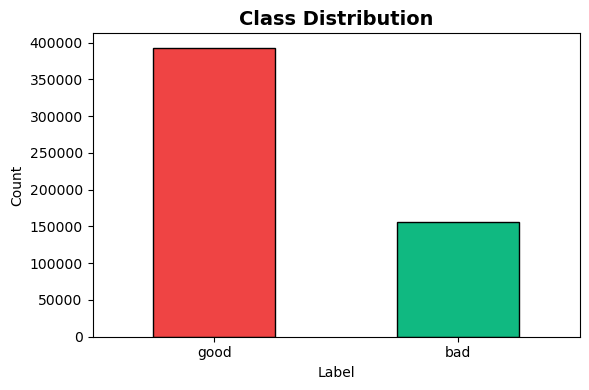

In [15]:
# Class distribution
print("Label Distribution:")
print(df['Label'].value_counts())
print(f"\nClass balance: {df['Label'].value_counts(normalize=True).round(3).to_dict()}")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df['Label'].value_counts().plot(kind='bar', ax=ax, color=['#ef4444', '#10b981'], edgecolor='black')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.tick_params(rotation=0)
plt.tight_layout()
plt.show()

Domain Intellience Features

In [16]:
# Known popular brands that phishing URLs often impersonate

KNOWN_BRANDS = [
    'paypal', 'google', 'facebook', 'apple', 'microsoft', 'amazon',
    'netflix', 'instagram', 'twitter', 'linkedin', 'ebay', 'dropbox',
    'chase', 'wellsfargo', 'bankofamerica', 'citibank', 'dhl', 'fedex',
    'whatsapp', 'telegram', 'yahoo', 'outlook', 'office365', 'adobe'
]

# Suspicious TLDs commonly used in phishing
SUSPICIOUS_TLDS = [
    'xyz', 'tk', 'ml', 'ga', 'cf', 'gq', 'top', 'click', 'link',
    'online', 'site', 'info', 'biz', 'pw', 'cc', 'ws', 'su'
]

def extract_features(url):
    """
    Extract 15 numerical features from a URL that are strong
    indicators of phishing activity.
    """
    url = str(url).lower().strip()
    features = {}

    # --- Basic URL structure ---
    features['url_length'] = len(url)
    features['dot_count'] = url.count('.')
    features['hyphen_count'] = url.count('-')
    features['slash_count'] = url.count('/')
    features['at_symbol'] = int('@' in url)           
    features['double_slash'] = int('//' in url[7:])   
    features['https'] = int(url.startswith('https')) 

    # --- IP address as domain ---
    # Phishing sites often use raw IPs to hide their identity
    ip_pattern = r'(http[s]?://)?(\d{1,3}\.){3}\d{1,3}'
    features['has_ip'] = int(bool(re.match(ip_pattern, url)))

    # --- Special character entropy (randomness) ---
    # Phishing URLs often have high character randomness
    special_chars = re.findall(r'[^a-zA-Z0-9/.:_-]', url)
    features['special_char_count'] = len(special_chars)

    # --- Domain analysis via tldextract ---
    ext = tldextract.extract(url)
    domain = ext.domain
    subdomain = ext.subdomain
    tld = ext.suffix

    features['subdomain_depth'] = len(subdomain.split('.')) if subdomain else 0
    features['domain_length'] = len(domain)
    features['suspicious_tld'] = int(tld in SUSPICIOUS_TLDS)

    # --- Brand spoofing detection ---
    # Check if a known brand name appears in subdomain/path but NOT as the main domain
    # e.g. "paypal.login-secure.com" — 'paypal' in subdomain, domain is 'login-secure'
    full_url_no_tld = (subdomain + '.' + domain).lower()
    brand_in_subdomain = any(brand in subdomain for brand in KNOWN_BRANDS)
    brand_is_domain = any(brand == domain for brand in KNOWN_BRANDS)
    features['brand_spoofing'] = int(brand_in_subdomain and not brand_is_domain)

    # --- Suspicious keywords in URL ---
    suspicious_words = ['login', 'signin', 'verify', 'secure', 'account',
                        'update', 'banking', 'confirm', 'password', 'credential',
                        'suspend', 'unusual', 'validate', 'alert', 'free', 'prize']
    features['suspicious_keyword_count'] = sum(1 for w in suspicious_words if w in url)

    # --- Path depth ---
    try:
        parsed = urlparse(url if url.startswith('http') else 'http://' + url)
        features['path_depth'] = len([p for p in parsed.path.split('/') if p])
    except:
        features['path_depth'] = 0

    return features

# Test on a few examples
test_urls = [
    'https://google.com/search?q=python',
    'http://paypal-login-verify.tk/account/secure',
    'http://192.168.1.1/admin/login.php',
    'https://amazon.com/dp/B09X5M6GCX',
    'http://secure-paypal.login-now.xyz/verify?user=123'
]

print("Feature extraction demo:\n")
demo_df = pd.DataFrame([extract_features(u) for u in test_urls], index=test_urls)
print(demo_df.T.to_string())

Feature extraction demo:

                          https://google.com/search?q=python  http://paypal-login-verify.tk/account/secure  http://192.168.1.1/admin/login.php  https://amazon.com/dp/B09X5M6GCX  http://secure-paypal.login-now.xyz/verify?user=123
url_length                                                34                                            44                                  34                                32                                                  50
dot_count                                                  1                                             1                                   4                                 1                                                   2
hyphen_count                                               0                                             2                                   0                                 0                                                   2
slash_count                                               

Extracting Features to the Entire Dataset

In [17]:
feature_df = df['URL'].apply(extract_features).apply(pd.Series)

print(f"\n Feature matrix shape: {feature_df.shape}")
print("\nFeature summary:")
print(feature_df.describe().round(2))


 Feature matrix shape: (549346, 15)

Feature summary:
       url_length  dot_count  hyphen_count  slash_count  at_symbol  \
count   549346.00  549346.00     549346.00    549346.00  549346.00   
mean        50.74       2.06          1.13         2.45       0.00   
std         44.42       1.51          2.42         1.60       0.06   
min          1.00       0.00          0.00         0.00       0.00   
25%         29.00       1.00          0.00         1.00       0.00   
50%         40.00       2.00          0.00         2.00       0.00   
75%         59.00       2.00          1.00         3.00       0.00   
max       2307.00      37.00         42.00        35.00       1.00   

       double_slash      https     has_ip  special_char_count  \
count     549346.00  549346.00  549346.00           549346.00   
mean           0.00       0.00       0.01                0.91   
std            0.06       0.01       0.12                3.65   
min            0.00       0.00       0.00             

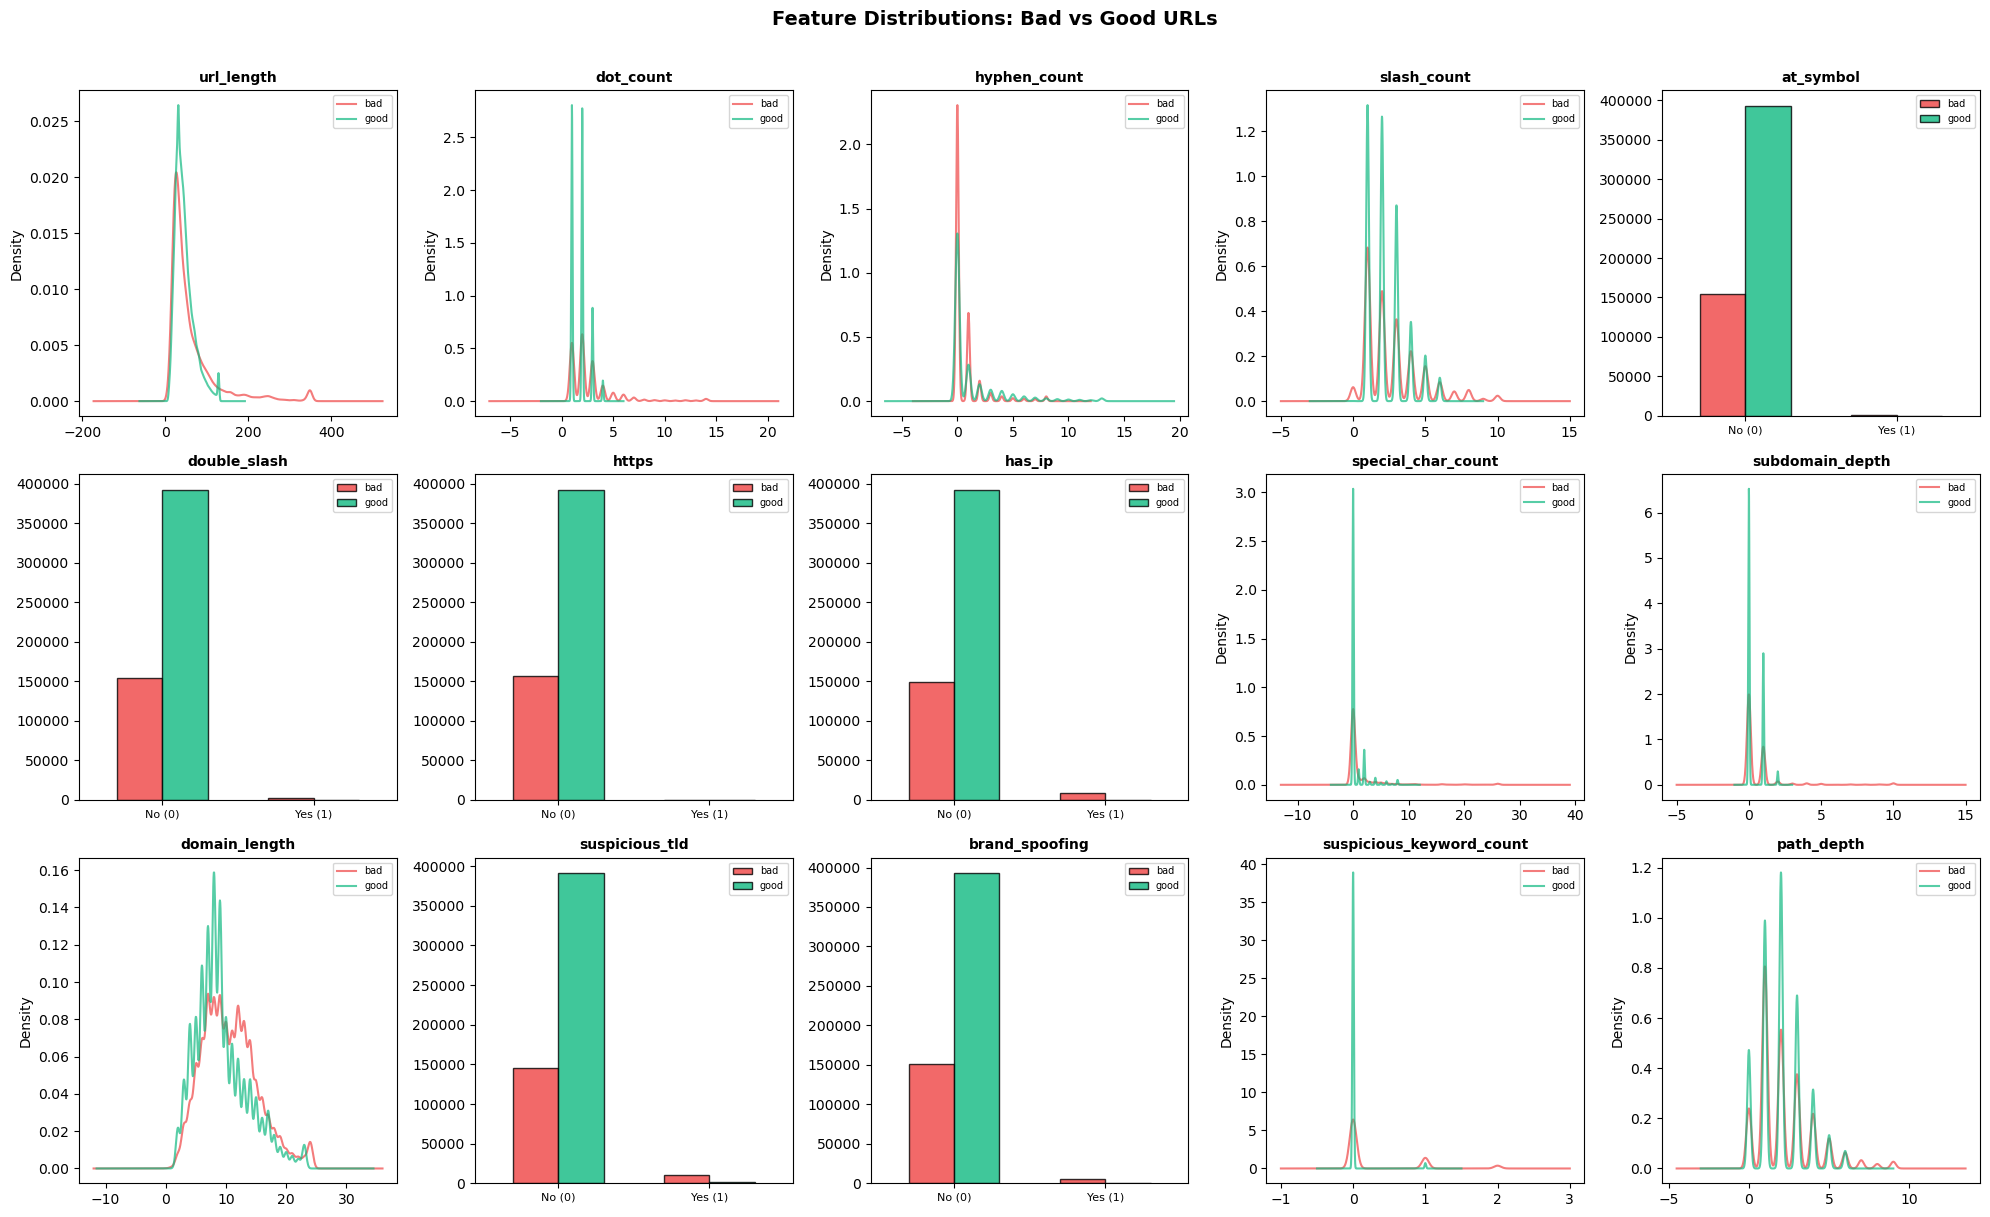

In [18]:
# Visualize feature distributions by class
# Binary features (only 0/1 values) use bar charts; continuous features use KDE plots

BINARY_FEATURES = ['at_symbol', 'double_slash', 'https', 'has_ip', 'brand_spoofing', 'suspicious_tld']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(feature_df.columns):
    ax = axes[i]
    is_binary = col in BINARY_FEATURES or feature_df[col].nunique() <= 2

    if is_binary:
        # Grouped bar chart for binary/categorical features
        counts = pd.DataFrame({
            'bad':  feature_df[col][df['Label'] == 'bad'].value_counts(),
            'good': feature_df[col][df['Label'] == 'good'].value_counts()
        }).fillna(0)
        counts.plot(kind='bar', ax=ax, color=['#ef4444', '#10b981'],
                    edgecolor='black', alpha=0.8, width=0.6)
        ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0, fontsize=8)
    else:
        # KDE plot for continuous features
        for label, color in [('bad', '#ef4444'), ('good', '#10b981')]:
            data = feature_df[col][df['Label'] == label]
            # Cap extreme outliers for cleaner plots
            upper = data.quantile(0.99)
            data.clip(upper=upper).plot(kind='kde', ax=ax, label=label,
                                        color=color, alpha=0.7)

    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

plt.suptitle('Feature Distributions: Bad vs Good URLs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# Same tokenization + stemming pipeline as original training,


tokenizer = RegexpTokenizer(r'[A-Za-z]+')
stemmer = SnowballStemmer('english')

def preprocess_url_text(url):
    """
    Tokenizes and stems URL text tokens.
    MUST be applied before vectorization — both at training and prediction time.
    """
    tokens = tokenizer.tokenize(str(url))
    stemmed = [stemmer.stem(t) for t in tokens]
    return ' '.join(stemmed)

print("Preprocessing URLs...")
df['text'] = df['URL'].apply(preprocess_url_text)
print("✅ Done")
print("\nSample preprocessed URLs:")
for i in range(3):
    print(f"  Original : {df['URL'].iloc[i]}")
    print(f"  Processed: {df['text'].iloc[i]}")
    print()

Preprocessing URLs...
✅ Done

Sample preprocessed URLs:
  Original : nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526
  Processed: nobel it ffb d dca cce f login skype com en cgi bin verif login ffb d dca cce f index php cmd profil ach outdat page tmpl p gen fail to load nav login access

  Original : www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading.php
  Processed: www dghjdgf com paypal co uk cycgi bin webscrcmd home custom nav load php

  Original : serviciosbys.com/paypal.cgi.bin.get-into.herf.secure.dispatch35463256rzr321654641dsf654321874/href/href/href/secure/center/update/limit/seccure/4d7a1ff5c55825a2e632a679c2fd5353/
  Processed: serviciosbi com paypal cgi bin get into herf secur dispatch rzr dsf href href href secur center updat limit seccur d a ff c a e a c fd



In [20]:
# TF-IDF Vectorizer — better than plain CountVectorizer because it
# down-weights tokens that appear in almost every URL (like 'com', 'www')
# and up-weights tokens that are more distinctive and informative.

print("Fitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(
    max_features=50000,    # Keeps only top 50k tokens (vs 350k in original)
    ngram_range=(1, 2),    # Also captures 2-word combos like 'login verify'
    sublinear_tf=True,     # Apply log normalization to term frequencies
    min_df=2               # Ignore tokens appearing in only 1 URL (likely noise)
)

tfidf_matrix = tfidf.fit_transform(df['text'])
print(f"✅ TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"   Vocabulary size: {len(tfidf.vocabulary_):,} tokens")

Fitting TF-IDF vectorizer...
✅ TF-IDF matrix shape: (549346, 50000)
   Vocabulary size: 50,000 tokens


Combining TF-IDF and Numerical Features into Hybrid Matrix

In [21]:
scaler = MinMaxScaler()
numerical_scaled = scaler.fit_transform(feature_df)
numerical_sparse = csr_matrix(numerical_scaled)

# Horizontally stack: [TF-IDF tokens | numerical features]
X_hybrid = hstack([tfidf_matrix, numerical_sparse])
y = df['Label']

print(f" Hybrid feature matrix shape: {X_hybrid.shape}")
print(f"   TF-IDF features: {tfidf_matrix.shape[1]:,}")
print(f"   Numerical features: {numerical_sparse.shape[1]}")
print(f"   Total features: {X_hybrid.shape[1]:,}")
print(f"\nClass distribution:\n{y.value_counts()}")

 Hybrid feature matrix shape: (549346, 50015)
   TF-IDF features: 50,000
   Numerical features: 15
   Total features: 50,015

Class distribution:
Label
good    392924
bad     156422
Name: count, dtype: int64


Train or Text split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y,
    test_size=0.25,
    random_state=42,
    stratify=y        # Ensures same class ratio in both splits
)

print(f"Training set:  {X_train.shape[0]:,} samples")
print(f"Test set:      {X_test.shape[0]:,} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set:  412,009 samples
Test set:      137,337 samples

Train class distribution:
Label
good    294693
bad     117316
Name: count, dtype: int64

Test class distribution:
Label
good    98231
bad     39106
Name: count, dtype: int64


Multi Model Training And Comparison

In [23]:
#Models Definitions to conpare
models = {
    'Naive Bayes (Multinomial)': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, solver='saga', n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=50,
        max_depth=20,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.5,
        random_state=42
    ),
}

results = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print('='*55)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    # AUC-ROC (use probability if available)
    if hasattr(model, 'predict_proba'):
        bad_idx = list(model.classes_).index('bad')
        y_proba = model.predict_proba(X_test)[:, bad_idx]
        auc = roc_auc_score((y_test == 'bad').astype(int), y_proba)
    else:
        auc = None

    results[name] = {
        'model': model,
        'accuracy': acc,
        'auc': auc,
        'y_pred': y_pred,
        'y_proba': y_proba if hasattr(model, 'predict_proba') else None
    }

    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    if auc: print(f"  AUC-ROC:  {auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

print("\n All models trained")


  Training: Naive Bayes (Multinomial)
  Accuracy: 0.9571 (95.71%)
  AUC-ROC:  0.9900

              precision    recall  f1-score   support

         Bad       0.96      0.89      0.92     39106
        Good       0.96      0.98      0.97     98231

    accuracy                           0.96    137337
   macro avg       0.96      0.94      0.95    137337
weighted avg       0.96      0.96      0.96    137337


  Training: Logistic Regression
  Accuracy: 0.9607 (96.07%)
  AUC-ROC:  0.9902

              precision    recall  f1-score   support

         Bad       0.97      0.89      0.93     39106
        Good       0.96      0.99      0.97     98231

    accuracy                           0.96    137337
   macro avg       0.96      0.94      0.95    137337
weighted avg       0.96      0.96      0.96    137337


  Training: Random Forest
  Accuracy: 0.7687 (76.87%)
  AUC-ROC:  0.9316

              precision    recall  f1-score   support

         Bad       1.00      0.19      0.32     

Cross Validation

In [24]:
# Cross-validation gives a more reliable accuracy estimate
# by testing on 5 different splits of the data
# Note: We skip GradientBoosting here as it's slow on full CV — you can uncomment

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

cv_models = {
    'Naive Bayes (Multinomial)': results['Naive Bayes (Multinomial)']['model'],
    'Logistic Regression': results['Logistic Regression']['model'],
    'Random Forest': results['Random Forest']['model'],
    # 'Gradient Boosting': results['Gradient Boosting']['model'],  # slow — uncomment if time permits
}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_hybrid, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}")
    print(f"  CV Scores: {scores.round(4)}")
    print(f"  Mean: {scores.mean():.4f} ± {scores.std():.4f}\n")

Naive Bayes (Multinomial)
  CV Scores: [0.9569 0.9574 0.9583 0.9571 0.9572]
  Mean: 0.9574 ± 0.0005

Logistic Regression
  CV Scores: [0.9616 0.962  0.9623 0.9609 0.9616]
  Mean: 0.9617 ± 0.0005

Random Forest
  CV Scores: [0.7754 0.7768 0.7805 0.7774 0.7766]
  Mean: 0.7773 ± 0.0017



Model Comparison chart

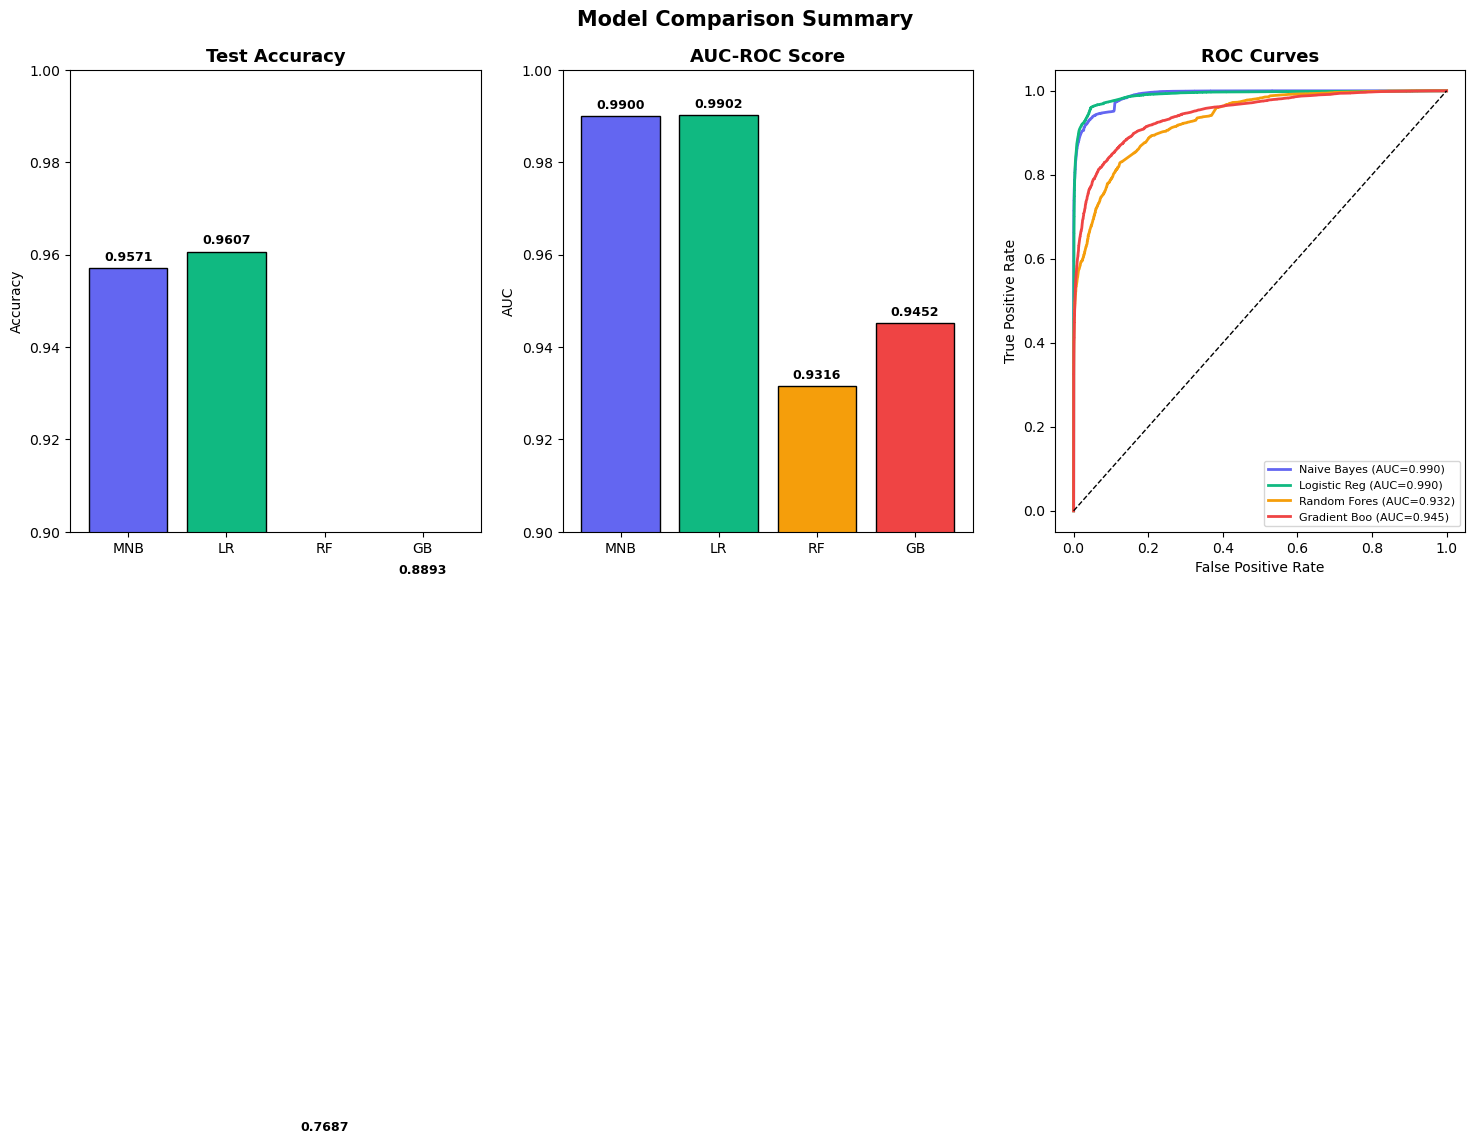

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
aucs = [results[m]['auc'] for m in model_names]
short_names = ['MNB', 'LR', 'RF', 'GB']

# Accuracy bar chart
bars = axes[0].bar(short_names, accuracies, color=['#6366f1','#10b981','#f59e0b','#ef4444'], edgecolor='black')
axes[0].set_ylim(0.9, 1.0)
axes[0].set_title('Test Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# AUC-ROC bar chart
bars2 = axes[1].bar(short_names, aucs, color=['#6366f1','#10b981','#f59e0b','#ef4444'], edgecolor='black')
axes[1].set_ylim(0.9, 1.0)
axes[1].set_title('AUC-ROC Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AUC')
for bar, auc in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{auc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ROC Curves
for name, color in zip(model_names, ['#6366f1','#10b981','#f59e0b','#ef4444']):
    if results[name]['y_proba'] is not None:
        fpr, tpr, _ = roc_curve((y_test == 'bad').astype(int), results[name]['y_proba'])
        short = name.split()[0] + (' ' + name.split()[1] if len(name.split()) > 1 else '')
        axes[2].plot(fpr, tpr, label=f"{short[:12]} (AUC={results[name]['auc']:.3f})", color=color, lw=2)

axes[2].plot([0,1],[0,1],'k--', lw=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Model Comparison Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Confusion Matrices

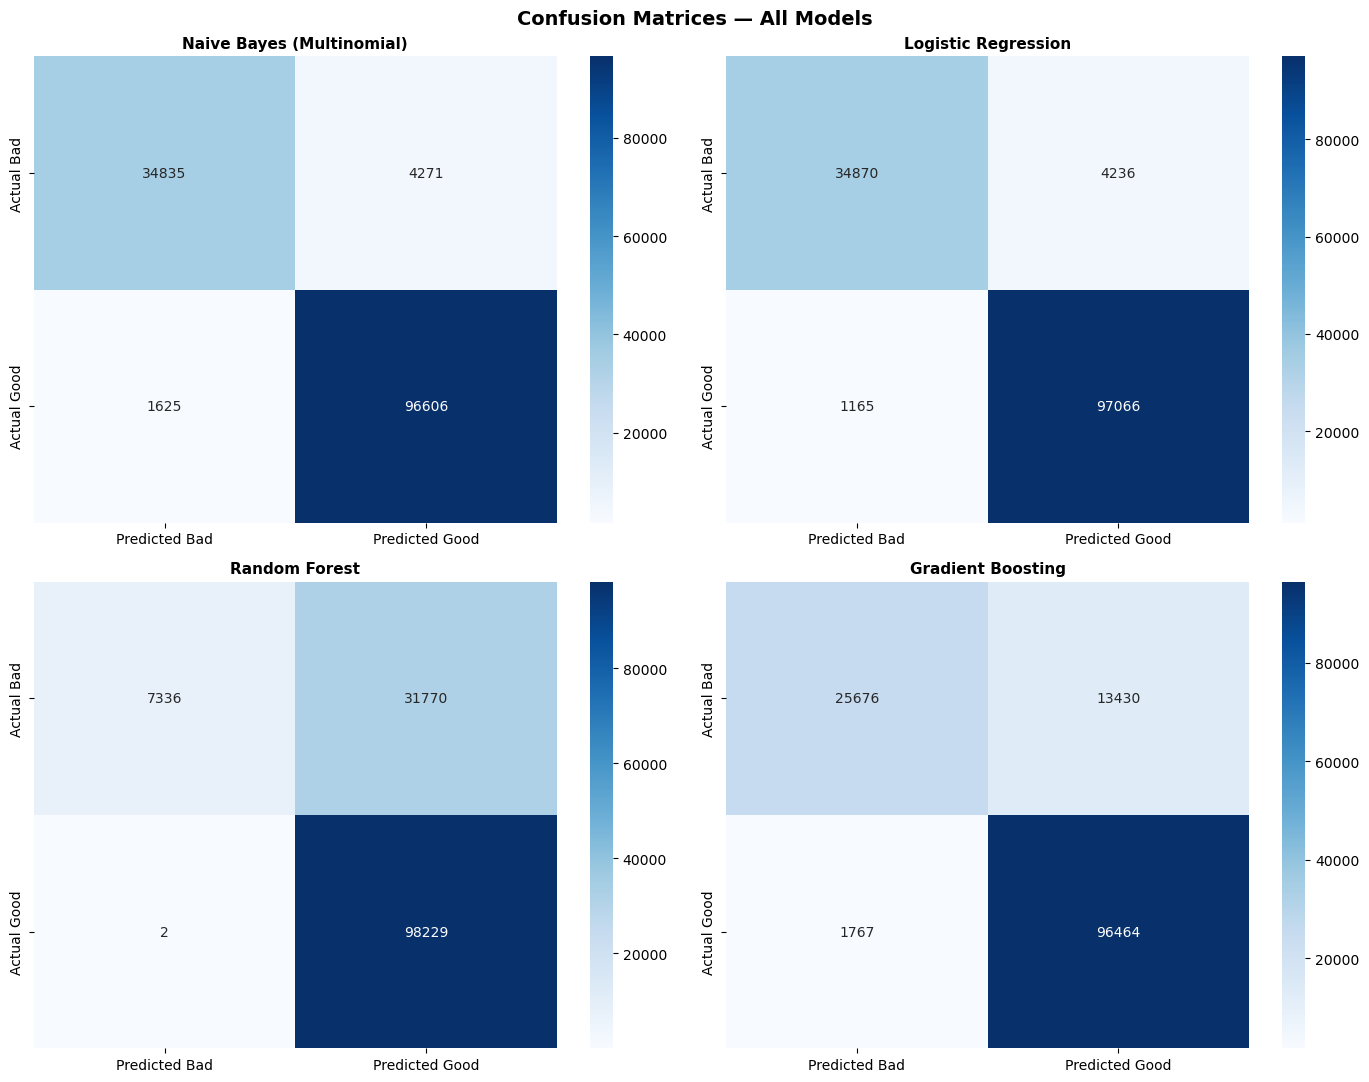

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'], labels=['bad', 'good'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Predicted Bad', 'Predicted Good'],
                yticklabels=['Actual Bad', 'Actual Good'])
    axes[i].set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Feature Importance(Random Forest)

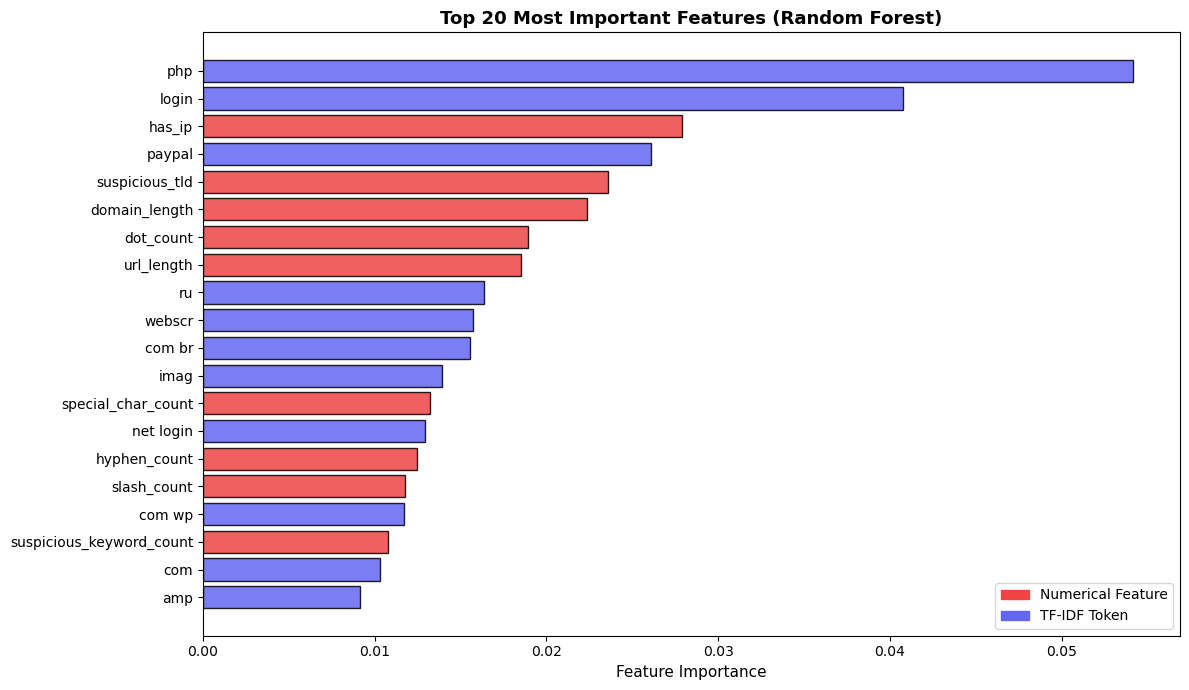


Top 10 features by importance:
  php                             0.054189
  login                           0.040792
  has_ip                          0.027876
  paypal                          0.026081
  suspicious_tld                  0.023577
  domain_length                   0.022381
  dot_count                       0.018951
  url_length                      0.018535
  ru                              0.016338
  webscr                          0.015732


In [27]:
rf_model = results['Random Forest']['model']

# Get feature names: TF-IDF tokens + numerical column names
tfidf_features = tfidf.get_feature_names_out()
num_features = np.array(feature_df.columns)
all_feature_names = np.concatenate([tfidf_features, num_features])

importances = rf_model.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(12, 7))
colors = ['#ef4444' if f in feature_df.columns else '#6366f1' for f in all_feature_names[top_idx]]
bars = plt.barh(range(top_n), importances[top_idx], color=colors, edgecolor='black', alpha=0.85)
plt.yticks(range(top_n), all_feature_names[top_idx], fontsize=10)
plt.xlabel('Feature Importance', fontsize=11)
plt.title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(color='#ef4444', label='Numerical Feature'), Patch(color='#6366f1', label='TF-IDF Token')]
plt.legend(handles=legend, loc='lower right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
for i in top_idx[:10]:
    print(f"  {all_feature_names[i]:30s}  {importances[i]:.6f}")

Domain Intelligence: Brand Spoofing Analysis

In [28]:
# Analyze how brand spoofing correlates with phishing
df['brand_spoofing'] = feature_df['brand_spoofing']
df['suspicious_tld'] = feature_df['suspicious_tld']
df['has_ip'] = feature_df['has_ip']

print("=== Brand Spoofing Analysis ===")
spoof_table = df.groupby(['brand_spoofing', 'Label']).size().unstack(fill_value=0)
spoof_table['phishing_rate'] = (spoof_table['bad'] / spoof_table.sum(axis=1) * 100).round(1)
print(spoof_table)

print("\n=== Suspicious TLD Analysis ===")
tld_table = df.groupby(['suspicious_tld', 'Label']).size().unstack(fill_value=0)
tld_table['phishing_rate'] = (tld_table['bad'] / tld_table.sum(axis=1) * 100).round(1)
print(tld_table)

print("\n=== IP Address as Domain ===")
ip_table = df.groupby(['has_ip', 'Label']).size().unstack(fill_value=0)
ip_table['phishing_rate'] = (ip_table['bad'] / ip_table.sum(axis=1) * 100).round(1)
print(ip_table)

=== Brand Spoofing Analysis ===
Label              bad    good  phishing_rate
brand_spoofing                               
0               151207  392852           27.8
1                 5215      72           98.6

=== Suspicious TLD Analysis ===
Label              bad    good  phishing_rate
suspicious_tld                               
0               145657  391183           27.1
1                10765    1741           86.1

=== IP Address as Domain ===
Label      bad    good  phishing_rate
has_ip                               
0       148594  392898           27.4
1         7828      26           99.7


=== Most Impersonated Brands in Phishing URLs ===



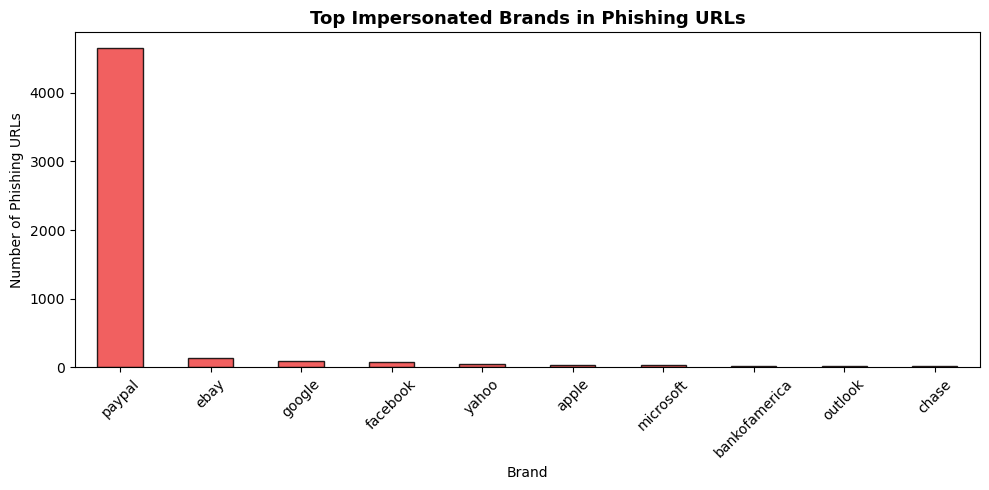

impersonated_brand
paypal           4649
ebay              135
google             97
facebook           82
yahoo              45
apple              35
microsoft          29
bankofamerica      27
outlook            26
chase              19


In [29]:
# Most impersonated brands in phishing URLs
print("=== Most Impersonated Brands in Phishing URLs ===\n")

def find_brand_in_url(url):
    ext = tldextract.extract(str(url).lower())
    subdomain = ext.subdomain
    domain_str = subdomain
    matches = [b for b in KNOWN_BRANDS if b in domain_str]
    return matches[0] if matches else None

phishing_only = df[df['Label'] == 'bad'].copy()
phishing_only['impersonated_brand'] = phishing_only['URL'].apply(find_brand_in_url)
brand_counts = phishing_only['impersonated_brand'].dropna().value_counts().head(10)

plt.figure(figsize=(10, 5))
brand_counts.plot(kind='bar', color='#ef4444', edgecolor='black', alpha=0.85)
plt.title('Top Impersonated Brands in Phishing URLs', fontsize=13, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Number of Phishing URLs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(brand_counts.to_string())

SAVING THE BEST MODEL

In [31]:
# Summary table
summary = pd.DataFrame({
    'Model': model_names,
    'Accuracy': [results[m]['accuracy'] for m in model_names],
    'AUC-ROC': [results[m]['auc'] for m in model_names],
}).set_index('Model').round(4)

print("=== Final Model Comparison ===")
print(summary.to_string())

best_name = summary['AUC-ROC'].idxmax()
print(f"\n Best Model: {best_name}")
print(f"   Accuracy: {summary.loc[best_name, 'Accuracy']:.4f}")
print(f"   AUC-ROC:  {summary.loc[best_name, 'AUC-ROC']:.4f}")

=== Final Model Comparison ===
                           Accuracy  AUC-ROC
Model                                       
Naive Bayes (Multinomial)    0.9571   0.9900
Logistic Regression          0.9607   0.9902
Random Forest                0.7687   0.9316
Gradient Boosting            0.8893   0.9452

 Best Model: Logistic Regression
   Accuracy: 0.9607
   AUC-ROC:  0.9902


In [32]:
# Save the best model and all required components for app.py

best_model = results[best_name]['model']

# Bundle everything the app needs into one file
pipeline_bundle = {
    'model': best_model,
    'tfidf': tfidf,
    'scaler': scaler,
    'feature_columns': list(feature_df.columns),
    'model_name': best_name
}

joblib.dump(pipeline_bundle, 'phishing_pipeline_v2.pkl')
print(f" Pipeline bundle saved: phishing_pipeline_v2.pkl")
print(f"   Contains: model ({best_name}), TF-IDF vectorizer, scaler, feature column names")

# Saving MNB
joblib.dump(results['Naive Bayes (Multinomial)']['model'], 'phishing_mnb_v2.pkl')
joblib.dump(tfidf, 'vectorizer_v2.pkl')
print(f"\n  saved: phishing_mnb_v2.pkl + vectorizer_v2.pkl (backward compatible)")

 Pipeline bundle saved: phishing_pipeline_v2.pkl
   Contains: model (Logistic Regression), TF-IDF vectorizer, scaler, feature column names

  saved: phishing_mnb_v2.pkl + vectorizer_v2.pkl (backward compatible)


REAL WORLD URLs TESTS

In [33]:
bundle = joblib.load('phishing_pipeline_v2.pkl')

# reimporting predicted_url from above cell
def predict_url(url, bundle):
    model = bundle['model']
    tfidf_v = bundle['tfidf']
    scaler_v = bundle['scaler']
    feature_columns = bundle['feature_columns']
    text = preprocess_url_text(url)
    tfidf_vec = tfidf_v.transform([text])
    feats = extract_features(url)
    num_array = [[feats[col] for col in feature_columns]]
    num_scaled = scaler_v.transform(num_array)
    num_sparse = csr_matrix(num_scaled)
    X = hstack([tfidf_vec, num_sparse])
    proba = model.predict_proba(X)[0]
    bad_idx = list(model.classes_).index('bad')
    return float(proba[bad_idx]) * 100

test_cases = [
    ('https://google.com/search?q=phishing',         'SHOULD BE SAFE'),
    ('https://github.com/user/repo',                 'SHOULD BE SAFE'),
    ('https://amazon.com/dp/B09X5M6GCX',             'SHOULD BE SAFE'),
    ('http://paypal-secure-login.com/verify',         'SHOULD BE PHISHING'),
    ('http://192.168.1.1/admin/login.php',            'SHOULD BE PHISHING'),
    ('http://secure-paypal.login-now.xyz/verify',     'SHOULD BE PHISHING'),
    ('http://amazon-deals.tk/win-free-prize-click',  'SHOULD BE PHISHING'),
    ('http://login-google.com.phishing-site.ml/',    'SHOULD BE PHISHING'),
    ('https://bankofamerica.com/online-banking',     'SHOULD BE SAFE'),
    ('http://bankofamerica-secure.update-now.xyz/',  'SHOULD BE PHISHING'),
]

print(f"{'URL':<50} {'Confidence':>12} {'Expected':<20}")
print("-" * 85)
for url, expected in test_cases:
    conf = predict_url(url, bundle)
    verdict = "PHISHING" if conf >= 50 else "SAFE"
    correct = "✓" if (("PHISHING" in expected) == (conf >= 50)) else "✗ WRONG"
    print(f"{url[:50]:<50} {conf:>10.1f}%  {verdict}  {correct}")

URL                                                  Confidence Expected            
-------------------------------------------------------------------------------------
https://google.com/search?q=phishing                      5.8%  SAFE  ✓
https://github.com/user/repo                             15.5%  SAFE  ✓
https://amazon.com/dp/B09X5M6GCX                          3.6%  SAFE  ✓
http://paypal-secure-login.com/verify                   100.0%  PHISHING  ✓
http://192.168.1.1/admin/login.php                      100.0%  PHISHING  ✓
http://secure-paypal.login-now.xyz/verify               100.0%  PHISHING  ✓
http://amazon-deals.tk/win-free-prize-click              94.2%  PHISHING  ✓
http://login-google.com.phishing-site.ml/               100.0%  PHISHING  ✓
https://bankofamerica.com/online-banking                 93.5%  PHISHING  ✗ WRONG
http://bankofamerica-secure.update-now.xyz/             100.0%  PHISHING  ✓
